

---

# 📘 Data Augmentation in Deep Learning: Complete Guide

> **Goal**: Understand *why*, *how*, and *when* to use data augmentation — not just the code, but the **core ideas** behind it.

---

## 🔍 1. What is Data Augmentation?

### ✅ Definition:
> **Data augmentation** is the process of artificially increasing the size and diversity of your training dataset by applying **random (but realistic) transformations** to existing images.

These transformations create **new, slightly modified versions** of the original images that still represent the same class.

---

### 🎯 Example:
You have **1 image of a cat**.  
With augmentation, you can generate:
- A rotated cat
- A flipped cat
- A zoomed-in cat
- A brighter/darker cat

Each looks different, but still a cat → perfect for training!

---

## 💡 2. Why Do We Need Data Augmentation?

### ❓ Problem: Overfitting
Deep neural networks have **millions of parameters**. If you train them on a small dataset, they **memorize** the data instead of **learning general patterns** → poor performance on new data.

This is called **overfitting**.

### ✅ Solution: Data Augmentation
It helps by:
- Increasing **effective dataset size**
- Improving **model generalization**
- Teaching the model to be **invariant** to irrelevant changes (e.g., rotation, lighting)

> 🧠 Think: "A cat is still a cat even if it's rotated or darker."

---

## 🧩 3. Key Intuitions Behind Augmentation

| Intuition | Explanation |
|--------|-------------|
| **Invariance Learning** | Teach model to ignore unimportant changes (e.g., position, brightness). A dog is still a dog whether it's on the left or right. |
| **Robustness** | Model sees varied versions during training → performs better on real-world messy data. |
| **Regularization Effect** | Acts like dropout or weight decay — prevents overfitting by adding "noise" through variation. |
| **Simulates Real-World Variability** | In real life, objects appear under different angles, lighting, scales — augmentation mimics this. |

---

## ⚙️ 4. How Does It Work Internally?

### 🔄 Step-by-Step Process:

1. **Take a batch of real images** from your dataset.
2. **Apply random transformations** (rotation, flip, etc.) on-the-fly.
3. **Feed transformed images** into the model during training.
4. **Repeat every epoch** — so the model never sees the exact same image twice.

> 🔁 No permanent copies are stored — transformations happen **in memory, during training**.

### 🧠 Behind the Scenes (Math & Code):
Transformations are applied using **affine transformations** and **pixel-level operations**:

| Transformation | Math/Operation |
|---------------|----------------|
| Rotation      | Affine matrix multiplication |
| Flip          | Reverse pixel indices (`img[:, ::-1, :]`) |
| Zoom/Crop     | Resize + center/random crop |
| Brightness    | Add/subtract from RGB values |
| Shift         | Translate pixels with padding |

These are fast and differentiable (for GPU acceleration).

---

## 🛠️ 5. Common Augmentations & When to Use Them

| Augmentation | Effect | Use When... |
|------------|--------|-------------|
| `RandomFlip` (horizontal) | Mirrors image | Objects are symmetric (cats, cars), not text |
| `RandomRotation` | Rotates image slightly | Camera angle varies |
| `RandomZoom` / `RandomCrop` | Simulates distance | Objects appear at different scales |
| `RandomBrightness/Contrast` | Changes lighting | Indoor/outdoor scenes vary |
| `RandomTranslation` | Moves object in frame | Object position varies |
| `RandomShear` | Skews shape | Perspective changes (e.g., tilted camera) |
| `Cutout` / `RandomErasing` | Blocks part of image | Forces model to use multiple features |
| `ColorJitter` (HSV shift) | Changes hue/saturation | Natural lighting variations |

> ✅ **Best Practice**: Only augment with **realistic variations** your model will see in real life.

---

## 🚫 6. What NOT to Do (Common Mistakes)

| Mistake | Why It's Bad | Fix |
|-------|--------------|-----|
| Flip text/images with text | Letters become unreadable | Avoid horizontal flip for text |
| Over-rotate road signs | A stop sign rotated 90° isn’t realistic | Limit rotation range |
| Augment validation/test set | Leaks info, inflates metrics | Only augment **training** data |
| Too aggressive augmentation | Images become unrecognizable | Keep changes subtle |
| Use augmentation on bounding boxes without sync | Boxes don’t match object | Use specialized tools like Albumentations |

---

## 📈 7. Impact on Model Performance

| Without Augmentation | With Augmentation |
|----------------------|-------------------|
| High training accuracy, low val accuracy (overfitting) | Training and val accuracy closer |
| Sensitive to lighting/angle | Robust to real-world variation |
| Needs large dataset | Can work with smaller datasets |
| Fast training (fewer ops) | Slightly slower due to transforms |

> ✅ **Typical gain**: +5–15% accuracy on small datasets.

---

## 🔄 8. Two Ways to Apply Augmentation

### ✅ Method 1: `ImageDataGenerator` (Legacy, Easy)
```python
datagen = ImageDataGenerator(rotation_range=20, horizontal_flip=True)
```
- Works well for **simple CNNs** and **beginners**
- Slower, CPU-bound
- Compatible with older Keras

### ✅ Method 2: **Keras Preprocessing Layers** (Modern, Best)
```python
augmenter = Sequential([
    RandomFlip(),
    RandomRotation(0.1),
    RandomZoom(0.2)
])
```
- Runs on **GPU**, faster
- Integrates with `tf.data` pipeline
- Recommended for **production and research**

> 🚀 Use **Method 2** if you're using TensorFlow 2.10+

---

## 🧪 9. Pro Tips & Best Practices

### ✅ General Tips:
1. **Start simple**: Begin with `RandomFlip + RandomRotation`
2. **Tune intensity**: Use small ranges (e.g., `rotation_range=10`, not 180)
3. **Match your domain**:
   - Medical images? Avoid flipping unless symmetric
   - Faces? Be careful with extreme zoom
4. **Visualize augmented images** — always check what you're feeding the model!
5. **Use per-channel augmentation** (e.g., hue shift only) for natural images

### ✅ Advanced Tips:
- **Mixup / CutMix**: Combine two images (advanced augmentation)
- **AutoAugment / RandAugment**: Learn best augmentations automatically
- **Per-batch augmentation**: Different transforms per batch → more diversity
- **Conditional augmentation**: Augment more for underrepresented classes

---

## 📊 10. Real-World Example: CIFAR-10

- Dataset: 50,000 training images (32x32)
- Without augmentation: ~85% accuracy
- With augmentation: ~92%+ accuracy

> 💥 That’s **7% improvement** — just from better data!

---

## 🧑‍🏫 Summary: The Big Picture

| Concept | Takeaway |
|-------|----------|
| **Purpose** | Prevent overfitting, improve generalization |
| **Mechanism** | On-the-fly transformation of training images |
| **Key Idea** | Teach invariance: "Same object, different look" |
| **Best Tool** | Keras `Random...` layers (GPU-accelerated) |
| **Golden Rule** | **Only augment training data**, never validation/test |
| **Design Rule** | Augmentations should reflect real-world variation |

---

## 📎 Bonus: When NOT to Use Augmentation?

| Scenario | Reason |
|--------|--------|
| Very large dataset (e.g., ImageNet) | Less benefit; model already generalizes |
| Highly structured data (e.g., medical scans) | Some transforms break anatomical meaning |
| You’re doing transfer learning with frozen base | Augmentation less critical |
| Debugging model behavior | Turn off augmentation to isolate issues |

---

## 🧩 Final Thought

> **Data augmentation is like showing your student slightly different versions of the same problem — so they learn the concept, not the example.**

It’s one of the **simplest yet most effective tricks** in deep learning.

---

## 📣 Want More?

Try this:
```python
# Try RandAugment (state-of-the-art)
tf.keras.layers.RandomAugmentation(value_range=(0, 255), magnitude=0.5)
```

Or explore libraries:
- [`albumentations`](https://albumentations.ai/) – Best for complex augmentations + bounding boxes
- [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) – PyTorch version

---



#Apply on single images

In [17]:
import tensorflow as tf
from tensorflow.keras import layers,models, optimizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

In [18]:
img = tf.keras.utils.load_img("/content/premium_photo-1666777247416-ee7a95235559.avif")

In [19]:
from PIL import Image

# Resize the image
img = Image.open("/content/premium_photo-1666777247416-ee7a95235559.avif")
img = img.resize((256, 256))

img_array = img_to_array(img)  # convert to numbers
img_array = img_array.reshape((1, 256, 256, 3))  # add batch dimension
display(img_array.shape)

(1, 256, 256, 3)

In [20]:
# 3. Make the augmenter (simple one)
datagen = ImageDataGenerator(
    rotation_range=20,      # turn a little
    width_shift_range=0.2,  # move left/right
    height_shift_range=0.2, # move up/down
    horizontal_flip=True,   # flip left-right
    zoom_range=0.2          # zoom in/out
)

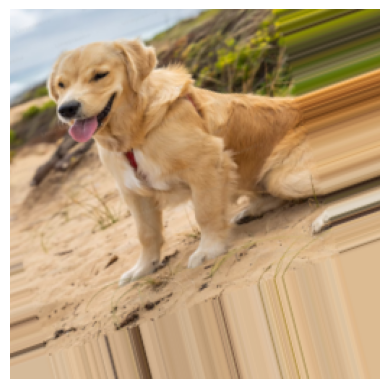

In [21]:
# 4. Generate one augmented image
it = datagen.flow(img_array, batch_size=1)

import matplotlib.pyplot as plt
aug_image = it[0][0]  # get first image

plt.imshow(aug_image.astype('uint8'))
plt.axis('off')
plt.show()

#Apply on lots image

In [12]:
import tensorflow as tf

# Load dataset (60k tiny images, 32x32)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values: 0-255 → 0-1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Training data shape:", x_train.shape)  # (50000, 32, 32, 3)
print("Training labels shape:", y_train.shape) # (50000, 1)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)


In [13]:
# Simple but effective augmentation
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,           # small rotate
    width_shift_range=0.1,       # move left/right
    height_shift_range=0.1,      # move up/down
    horizontal_flip=True,        # flip left-right (good for animals, cars)
    zoom_range=0.1               # zoom in/out a bit
)

In [14]:
# Feed training data into the generator
train_generator = datagen.flow(x_train, y_train, batch_size=32)

In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')  # 10 classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train using augmented data
model.fit(train_generator, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - accuracy: 0.3485 - loss: 1.7827 - val_accuracy: 0.5039 - val_loss: 1.3760
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.5276 - loss: 1.3208 - val_accuracy: 0.5844 - val_loss: 1.1894
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.5854 - loss: 1.1771 - val_accuracy: 0.6402 - val_loss: 1.0230
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.6055 - loss: 1.1177 - val_accuracy: 0.6675 - val_loss: 0.9656
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 26ms/step - accuracy: 0.6286 - loss: 1.0561 - val_accuracy: 0.6609 - val_loss: 0.9890


In [25]:
import tensorflow as tf
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

In [26]:
(x_train,y_train),_ = tf.keras.datasets.cifar10.load_data()

In [27]:
x_train = x_train.astype('float32')/255.0


In [28]:
augmenter = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.2)
])


In [30]:
batch = tf.expand_dims(x_train[0], 0)  # (1, 32, 32, 3)
aug_img = augmenter(batch, training=True)[0]  # (32, 32, 3)

#Modern Approach

In [32]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

# 1. Define augmenter ONCE
augment = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.2),
])

# 2. Use in pipeline
def train_preprocess(img, label):
    return augment(img, training=True), label

In [33]:
# Load data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Convert to dataset
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))

# Normalize + augment
def preprocess(img, label):
    img = tf.cast(img, tf.float32) / 255.0
    return augment(img, training=True), label

train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(32).prefetch(1)



---

## 🔍 Data Augmentation: Interview Q&A (Minimalist & Strong)

---

### **Q1: What is data augmentation?**

**A:**  
Data augmentation is a technique to **artificially increase the size and diversity** of a training dataset by applying **realistic transformations** (like flip, rotate, zoom) to existing images.

It helps improve model generalization and reduce overfitting.

> ✅ Example: A cat image flipped horizontally is still a cat.

---

### **Q2: Why do we use data augmentation?**

**A:**  
We use it to:
- Prevent overfitting (especially with small datasets)
- Improve model robustness to real-world variations (lighting, angle, scale)
- Teach invariance (e.g., "a dog is still a dog if rotated")
- Simulate more training data without manual labeling

> 📈 Result: Better accuracy on unseen data.

---

### **Q3: What are common augmentation techniques?**

**A:**  
| Technique | Purpose |
|--------|--------|
| `RandomFlip` | Horizontal/vertical flip |
| `RandomRotation` | Slight rotation (±10–20°) |
| `RandomZoom` | Simulate distance |
| `RandomBrightness` | Handle lighting changes |
| `RandomContrast` | Improve robustness |
| `RandomCrop` | Focus on parts of object |
| `CutOut` / `RandomErasing` | Force model to use multiple features |

> ✅ Best: Use combinations that match real-world use.

---

### **Q4: When should you NOT use data augmentation?**

**A:**  
Avoid or limit augmentation when:
- The transformation breaks meaning (e.g., flipping text, rotating numbers)
- Dataset is already very large (e.g., ImageNet)
- You’re augmenting **validation/test data** (never do this!)
- The domain is sensitive (e.g., medical images — flipping anatomy is wrong)

> ❌ Golden Rule: Only augment **training data**.

---

### **Q5: What’s the difference between `ImageDataGenerator` and modern layers?**

| `ImageDataGenerator` | Modern Layers (`tf.keras.layers`) |
|----------------------|-----------------------------------|
| Legacy, CPU-based | GPU-accelerated |
| Slower, deprecated | Fast, recommended |
| Works with `.flow()` | Works in `tf.data` pipelines |
| Hard to customize | Easy to compose |

> ✅ **Use modern layers** for new projects:
```python
augment = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1)
])
```

---

### **Q6: How do you apply augmentation in `tf.data`?**

**A:**  
```python
def augment(image, label):
    image = augmenter(image, training=True)
    return image, label

train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(32).prefetch(1)
```

> ✅ Key: Use `.map()` + `training=True` + `AUTOTUNE` for speed.

---

### **Q7: Should you normalize before or after augmentation?**

**A:**  
✅ **Normalize first**, then augment.

```python
def normalize(img, label):
    img = tf.cast(img, tf.float32) / 255.0  # → [0,1]
    return img, label

def augment(img, label):
    return augmenter(img, training=True), label
```

> Why? Some augmentations (like brightness) assume normalized range.

---

### **Q8: What is the role of `training=True`?**

**A:**  
It **enables randomness** in layers like `RandomFlip`.

- `training=True` → Apply random transform
- `training=False` → Do nothing (important for inference)

> ✅ Always use `training=True` during training.

---

### **Q9: Can you use data augmentation in NLP or audio?**

**A:**  
Yes!

- **NLP**: Synonym replacement, back-translation, random deletion
- **Audio**: Speed change, noise injection, pitch shift
- **Time Series**: Jittering, scaling, window slicing

> Augmentation is **not just for images**.

---

### **Q10: What are advanced augmentation methods?**

**A:**  
- **MixUp**: Combine two images and labels
- **CutMix**: Cut part of one image and paste on another
- **AutoAugment**: Learn best policies from data
- **RandAugment**: Randomly sample from a set (simpler than AutoAugment)

> Used in SOTA models (e.g., EfficientNet, ViT).

---

### **Q11: How do you debug augmentation?**

**A:**  
- Visualize augmented images before training
- Check if labels still match (e.g., after CutMix)
- Ensure no data leakage
- Avoid over-augmenting (e.g., 180° rotation for faces)

> 🔍 Pro Tip: Run a batch through and plot 5–10 samples.

---

### **Q12: Does augmentation help transfer learning?**

**A:**  
✅ Yes — even with pre-trained models.

Fine-tuning benefits from augmentation because:
- It adapts the model to your **specific data distribution**
- Helps prevent overfitting on small custom datasets
- Improves robustness beyond ImageNet-style data

> But: Don’t overdo it — start mild.

---

## ✅ Summary: Key Rules

| Rule | Why |
|------|-----|
| ✅ Only augment training data | Avoid data leakage |
| ✅ Use `training=True` | Enable randomness |
| ✅ Normalize first | Stable training |
| ✅ Use modern layers | Faster, GPU-friendly |
| ✅ Match real-world use | No unrealistic flips/rotations |

---


